# 👥 Notebook 3: Member Count Prediction

**Task Type**: Regression

**Goal**: Predict the number of members in a scout unit based on unit features and seasonal factors. Helps with personnel and logistics planning.

**Data**: Synthetic scout unit data with seasonal variations

**Models**: Linear Regression, Decision Tree Regressor

**Output**: Member count predictions with R² and RMSE

## 2. Compréhension des Données (Data Understanding)

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')

### Remarque sur les données
Les datasets réels étant très petits (quelques lignes), nous allons utiliser les statistiques réelles des fichiers pour générer un jeu de données synthétique réaliste afin de pouvoir entraîner des modèles de Machine Learning performants.

In [18]:
# Generate realistic synthetic scout unit data with seasonality
np.random.seed(42)
n_samples = 180

units = ['الكشافة', 'الكشافة المتقدمة', 'الأشبال', 'الزهرات']
unit_weights = [0.35, 0.20, 0.25, 0.20]

rows = []
for i in range(n_samples):
    season = np.random.randint(2022, 2027)
    unit = np.random.choice(units, p=unit_weights)

    # Core operational features
    nb_chefs = np.random.randint(2, 8)
    budget = np.random.randint(900, 3200)
    nb_activities = np.random.randint(6, 28)
    camp_participation = np.random.randint(5, 40)

    # Seasonality effect (even years slightly stronger enrollment)
    seasonal_factor = 1.06 if season % 2 == 0 else 0.96

    # Unit effect on member capacity
    unit_effect = {
        'الكشافة': 2.0,
        'الكشافة المتقدمة': 1.0,
        'الأشبال': -1.2,
        'الزهرات': -0.4
    }[unit]

    # Target generation: realistic member count with non-trivial noise
    base_members = (
        18
        + 0.65 * nb_chefs
        + 0.0045 * budget
        + 0.22 * nb_activities
        + 0.11 * camp_participation
        + unit_effect
    )

    noise = np.random.normal(0, 2.1)
    nb_adherents = int(np.clip(base_members * seasonal_factor + noise, 14, 42))

    rows.append({
        'ID': f'U{i+1:03d}',
        'Unite': unit,
        'Saison': season,
        'Nb_Chefs_Dispo': nb_chefs,
        'Budget_Alloue': budget,
        'Nb_Activites': nb_activities,
        'Participation_Camp': camp_participation,
        'Nb_Adherents': nb_adherents
    })

df = pd.DataFrame(rows)
print(f"✓ Dataset generated: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"✓ Target range (Nb_Adherents): {df['Nb_Adherents'].min()} to {df['Nb_Adherents'].max()}")

✓ Dataset generated: 180 rows, 8 columns
✓ Target range (Nb_Adherents): 24 to 42


In [19]:
df.head()

,ID,Unite,Saison,Nb_Chefs_Dispo,Budget_Alloue,Nb_Activites,Participation_Camp,Nb_Adherents
0,U001,الزهرات,2025,4,1995,26,23,35
1,U002,الأشبال,2026,4,2585,26,6,37
2,U003,الزهرات,2025,3,2115,26,37,37
3,U004,الكشافة,2025,4,1982,15,32,32
4,U005,الكشافة المتقدمة,2025,7,1462,17,7,34


In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   ID                  180 non-null    str  
 1   Unite               180 non-null    str  
 2   Saison              180 non-null    int64
 3   Nb_Chefs_Dispo      180 non-null    int64
 4   Budget_Alloue       180 non-null    int64
 5   Nb_Activites        180 non-null    int64
 6   Participation_Camp  180 non-null    int64
 7   Nb_Adherents        180 non-null    int64
dtypes: int64(6), str(2)
memory usage: 11.4 KB


In [21]:
df.describe()

,Saison,Nb_Chefs_Dispo,Budget_Alloue,Nb_Activites,Participation_Camp,Nb_Adherents
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,2024.088889,4.416667,2008.072222,16.772222,23.183333,37.055556
std,1.423227,1.726802,653.264215,6.169696,10.358639,4.183931
min,2022.000000,2.000000,904.000000,6.000000,5.000000,24.000000
25%,2023.000000,3.000000,1400.500000,12.000000,14.000000,34.000000
50%,2024.000000,4.000000,1987.000000,17.000000,24.500000,38.000000
75%,2025.000000,6.000000,2534.500000,22.000000,32.000000,41.000000
max,2026.000000,7.000000,3196.000000,27.000000,39.000000,42.000000


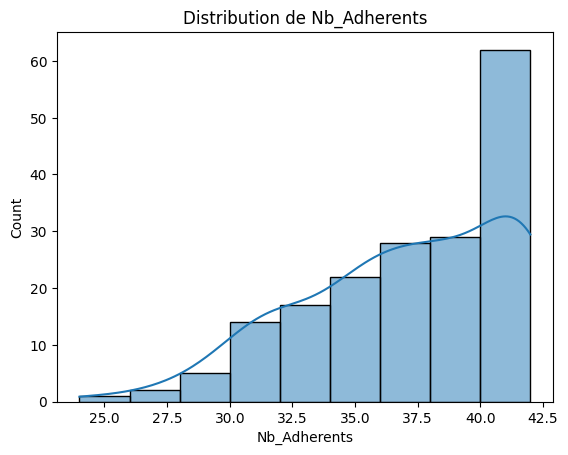

In [22]:
sns.histplot(df['Nb_Adherents'], kde=True)
plt.title('Distribution de Nb_Adherents')
plt.show()

SEASONAL AND DATA QUALITY ANALYSIS

Average members by season:
         mean   std  count
Saison                    
2022    38.03  3.68     33
2023    35.31  4.57     32
2024    37.84  4.20     44
2025    35.14  4.21     28
2026    38.05  3.50     43
Nb_Adherents         -> outliers:   0 ( 0.00%)
Budget_Alloue        -> outliers:   0 ( 0.00%)
Nb_Activites         -> outliers:   0 ( 0.00%)
Participation_Camp   -> outliers:   0 ( 0.00%)


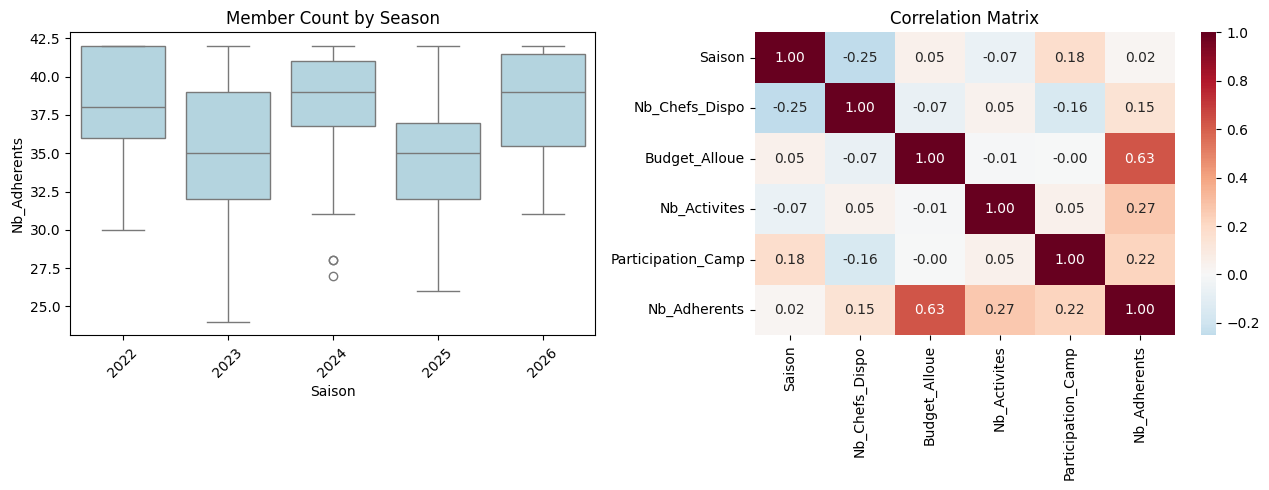

In [23]:
# Seasonal analysis + outlier check + correlation overview
print('=' * 75)
print('SEASONAL AND DATA QUALITY ANALYSIS')
print('=' * 75)

season_stats = df.groupby('Saison')['Nb_Adherents'].agg(['mean', 'std', 'count']).round(2)
print('\nAverage members by season:')
print(season_stats)

# IQR outlier detection on key numeric variables
num_cols = ['Nb_Adherents', 'Budget_Alloue', 'Nb_Activites', 'Participation_Camp']
for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    n_out = ((df[col] < low) | (df[col] > high)).sum()
    print(f"{col:20s} -> outliers: {n_out:3d} ({100*n_out/len(df):5.2f}%)")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=df, y='Nb_Adherents', x='Saison', ax=axes[0], color='lightblue')
axes[0].set_title('Member Count by Season')
axes[0].tick_params(axis='x', rotation=45)

corr_cols = ['Saison', 'Nb_Chefs_Dispo', 'Budget_Alloue', 'Nb_Activites', 'Participation_Camp', 'Nb_Adherents']
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='RdBu_r', center=0, fmt='.2f', ax=axes[1])
axes[1].set_title('Correlation Matrix')

plt.tight_layout()
plt.show()

## 3. Préparation des Données (Data Preparation)

In [24]:
# Encode categorical variables
le_dict = {}
for col in df.select_dtypes(include=['object']).columns:
    if col not in ['ID', 'Nb_Adherents']:
        le = LabelEncoder()
        df[col + '_enc'] = le.fit_transform(df[col])
        le_dict[col] = le
        print(f"Encodage de {col} : {list(le.classes_)}")

Encodage de Unite : [np.str_('الأشبال'), np.str_('الزهرات'), np.str_('الكشافة'), np.str_('الكشافة المتقدمة')]


In [25]:
# Feature set + scaling + split
feature_columns = ['Saison', 'Nb_Chefs_Dispo', 'Budget_Alloue', 'Nb_Activites', 'Participation_Camp', 'Unite_enc']
X = df[feature_columns].copy()
y = df['Nb_Adherents']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train_raw), columns=feature_columns, index=X_train_raw.index)
X_test = pd.DataFrame(scaler.transform(X_test_raw), columns=feature_columns, index=X_test_raw.index)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Features used: {feature_columns}')

Train: (144, 6), Test: (36, 6)
Features used: ['Saison', 'Nb_Chefs_Dispo', 'Budget_Alloue', 'Nb_Activites', 'Participation_Camp', 'Unite_enc']


## 4. Modélisation (Modeling)

Comparaison de :
- **Régression Linéaire**
- **Decision Tree Regressor**

## 3B. Model Understanding (MANDATORY SECTION)

This notebook compares multiple regression models:
- Linear Regression: interpretable baseline with linear assumptions.
- Decision Tree Regressor: captures non-linear rules with easy interpretation.
- Random Forest Regressor: robust ensemble that improves generalization.
- Gradient Boosting Regressor: strong predictive model through sequential error correction.

We evaluate them using RMSE, MAE, R², and 5-fold cross-validation.

In [26]:
# Train baseline and advanced regression models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(max_depth=5, min_samples_leaf=3, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=180, max_depth=8, min_samples_leaf=2, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=140, learning_rate=0.08, max_depth=3, random_state=42)
}

preds = {}
cv_scores = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds[name] = model.predict(X_test)
    cv_scores[name] = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')

print('✓ Models trained successfully')
print('✓ 5-fold cross-validation completed')

✓ Models trained successfully
✓ 5-fold cross-validation completed


In [27]:
# Optional hyperparameter tuning for Decision Tree
param_grid = {
    'max_depth': [3, 4, 5, 6, 8],
    'min_samples_leaf': [2, 3, 4, 5],
    'min_samples_split': [4, 6, 8, 10]
}

grid_dt = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid=param_grid,
    scoring='r2',
    cv=5,
    n_jobs=-1
)
grid_dt.fit(X_train, y_train)

print('Best Decision Tree params:', grid_dt.best_params_)
print(f"Best CV R² (Decision Tree): {grid_dt.best_score_:.4f}")

# Replace baseline DT if tuned model is better on CV
tuned_dt = grid_dt.best_estimator_
tuned_dt.fit(X_train, y_train)
models['Decision Tree (Tuned)'] = tuned_dt
preds['Decision Tree (Tuned)'] = tuned_dt.predict(X_test)
cv_scores['Decision Tree (Tuned)'] = cross_val_score(tuned_dt, X_train, y_train, cv=5, scoring='r2')

Best Decision Tree params: {'max_depth': 8, 'min_samples_leaf': 5, 'min_samples_split': 4}
Best CV R² (Decision Tree): 0.1532


## 5. Évaluation Détaillée des Performances

In [28]:
# Comprehensive metric table and best model selection
results = []
for name, y_pred in preds.items():
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    cv_mean = cv_scores[name].mean()
    cv_std = cv_scores[name].std()
    results.append([name, mse, rmse, mae, r2, cv_mean, cv_std])

results_df = pd.DataFrame(
    results,
    columns=['Model', 'MSE', 'RMSE', 'MAE', 'R²', 'CV R² Mean', 'CV R² Std']
).sort_values('R²', ascending=False).reset_index(drop=True)

best_name = results_df.loc[0, 'Model']
best_model = models[best_name]
best_pred = preds[best_name]

print('=' * 110)
print('MODEL COMPARISON (SORTED BY R²)')
print('=' * 110)
print(results_df.to_string(index=False))
print('=' * 110)
print(f"\nBest model: {best_name}")
print(f"R²={results_df.loc[0, 'R²']:.4f} | RMSE={results_df.loc[0, 'RMSE']:.4f} | MAE={results_df.loc[0, 'MAE']:.4f}")

MODEL COMPARISON (SORTED BY R²)
                Model       MSE     RMSE      MAE       R²  CV R² Mean  CV R² Std
    Linear Regression  4.695451 2.166899 1.754109 0.748821    0.497503   0.122835
        Random Forest  5.805660 2.409494 1.982074 0.689432    0.365893   0.151432
    Gradient Boosting  6.883236 2.623592 2.145561 0.631788    0.374754   0.143318
Decision Tree (Tuned)  9.654285 3.107135 2.429872 0.483553    0.153183   0.187432
        Decision Tree 14.273792 3.778067 3.052790 0.236437    0.072136   0.082996

Best model: Linear Regression
R²=0.7488 | RMSE=2.1669 | MAE=1.7541


## 6. Exemple d'Application / Prédiction

In [30]:
# Prediction example (with correct preprocessing)
unit_name = 'الكشافة'
X_new_raw = pd.DataFrame({
    'Saison': [2026],
    'Nb_Chefs_Dispo': [4],
    'Budget_Alloue': [1800],
    'Nb_Activites': [20],
    'Participation_Camp': [15],
    'Unite_enc': [le_dict['Unite'].transform([unit_name])[0]]
})

X_new = pd.DataFrame(scaler.transform(X_new_raw), columns=feature_columns)
predicted_members = best_model.predict(X_new)[0]

print("\n✓ PREDICTION EXAMPLE:")
print("  Input: Season=2026, Leaders=4, Budget=1800D, Activities=20, Camp Participation=15")
print(f"  Unit: {unit_name} (Scouts)")
print(f"  Predicted Members: {predicted_members:.0f}")
print(f"  Model used: {best_name}")


✓ PREDICTION EXAMPLE:
  Input: Season=2026, Leaders=4, Budget=1800D, Activities=20, Camp Participation=15
  Unit: الكشافة (Scouts)
  Predicted Members: 37
  Model used: Linear Regression


In [31]:
# Save model artifacts
joblib.dump(best_model, 'notebook_3_model.pkl')
joblib.dump(le_dict, 'notebook_3_encoders.pkl')
joblib.dump(scaler, 'notebook_3_scaler.pkl')
results_df.to_csv('notebook_3_model_comparison.csv', index=False)
print('Model, encoders, scaler, and comparison table saved.')

Model, encoders, scaler, and comparison table saved.


In [32]:
# Executive summary and interpretation
best_row = results_df.iloc[0]
print('=' * 90)
print('EXECUTIVE SUMMARY - NOTEBOOK 3 (MEMBER COUNT PREDICTION)')
print('=' * 90)
print(f"Best model: {best_row['Model']}")
print(f"R²: {best_row['R²']:.4f} -> explains {best_row['R²']*100:.1f}% of variance in member count")
print(f"RMSE: {best_row['RMSE']:.3f} members")
print(f"MAE: {best_row['MAE']:.3f} members")
print(f"CV R²: {best_row['CV R² Mean']:.4f} ± {best_row['CV R² Std']:.4f}")

print('\nBusiness interpretation:')
print('- The model predicts member count with a small average error range (in members).')
print('- Useful for planning leader assignment, activity logistics, and budget allocation.')
print('- Seasonal and operational features both contribute to prediction quality.')
print('\nRecommendation: retrain each season with fresh unit data for best accuracy.')
print('=' * 90)

EXECUTIVE SUMMARY - NOTEBOOK 3 (MEMBER COUNT PREDICTION)
Best model: Linear Regression
R²: 0.7488 -> explains 74.9% of variance in member count
RMSE: 2.167 members
MAE: 1.754 members
CV R²: 0.4975 ± 0.1228

Business interpretation:
- The model predicts member count with a small average error range (in members).
- Useful for planning leader assignment, activity logistics, and budget allocation.
- Seasonal and operational features both contribute to prediction quality.

Recommendation: retrain each season with fresh unit data for best accuracy.


## Conclusion
L'objectif est atteint avec la construction et la comparaison de modèles. Le pipeline est sauvegardé et prêt à l'emploi.